# DataDriven_Soccer_Scouting

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras import layers, models
from sklearn.cluster import KMeans
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
import time
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "nbformat"])

import warnings
warnings.filterwarnings("ignore")

start_time = time.time()

## Introduction and EDA

In [2]:
df = pd.read_csv("merged_data.csv")
# Convert 'season' to a more readable format (e.g., '2020 - 2021')
df['season'] = df['season'].astype(str).str.zfill(4)
df['season'] = "20" + df['season'].str[:2] + " - 20" + df['season'].str[2:]

# Keep "Position" column instead of "pos"
df.drop(columns=['pos'], inplace=True)
df = df.rename(columns={'Position': 'pos'})

display(df.head())
print('\nRows: {}, Columns: {}'.format(df.shape[0], df.shape[1]))

,league,season,team,player,nation,age,born,Playing Time_MP,Playing Time_Starts,Playing Time_Min,...,Touches_Att Pen,Touches_Def 3rd,Touches_Def Pen,Touches_Live,Touches_Mid 3rd,Touches_Touches,Height,Weight,Preferred foot,pos
0,ENG-Premier League,2024 - 2025,Arsenal,Ben White,ENG,26,1997,17,13,1198,...,28,214,55,813,367,813,NaN,NaN,NaN,NaN
1,ENG-Premier League,2024 - 2025,Arsenal,Bukayo Saka,ENG,22,2001,25,20,1729,...,162,57,6,978,216,979,178.0,65.0,Left,RW
2,ENG-Premier League,2024 - 2025,Arsenal,David Raya,ESP,28,1995,38,38,3420,...,0,1388,880,1480,92,1480,183.0,75.0,Right,GK
3,ENG-Premier League,2024 - 2025,Arsenal,Declan Rice,ENG,25,1999,35,33,2825,...,81,325,82,1948,909,1948,185.0,80.0,Right,CDM
4,ENG-Premier League,2024 - 2025,Arsenal,Gabriel Magalhães,BRA,26,1997,28,28,2363,...,40,672,189,1873,985,1873,NaN,NaN,NaN,NaN



Rows: 4807, Columns: 117


In [3]:
# Removing rows with null values and Goalkeepers (GK)
not_null_df = df.dropna()
not_null_df = not_null_df[not_null_df['pos'] != 'GK']
print('data without null and GKs\n- rows: {} \n- columns: {}'.format(not_null_df.shape[0], not_null_df.shape[1]))
df_backup = df.copy()
df = not_null_df.copy()

data without null and GKs
- rows: 3392 
- columns: 117


In [4]:
# Select all not numeric columns
not_numeric_cols = df.select_dtypes(exclude=[np.number]).columns
display(df[not_numeric_cols].head())

,league,season,team,player,nation,Preferred foot,pos
1,ENG-Premier League,2024 - 2025,Arsenal,Bukayo Saka,ENG,Left,RW
3,ENG-Premier League,2024 - 2025,Arsenal,Declan Rice,ENG,Right,CDM
5,ENG-Premier League,2024 - 2025,Arsenal,Gabriel Martinelli,BRA,Right,LW
6,ENG-Premier League,2024 - 2025,Arsenal,Jakub Kiwior,POL,Left,CB
7,ENG-Premier League,2024 - 2025,Arsenal,Jurriën Timber,NED,Right,RB


In [5]:
# Convert preferred_foot to binary (1 for 'Right', 0 for 'Left')
df.rename(columns={'Preferred foot': 'preferred_foot'}, inplace=True)
df['preferred_foot_binary'] = df['preferred_foot'].map({'Right': 1, 'Left': 0})

# Identify info columns and create a separate DataFrame for them
info_columns = ['league', 'season', 'team', 'player', 'nation', 'pos', 'born', 'age', 'preferred_foot']
df_info = df[[col for col in df.columns if col.lower() in info_columns]].copy()
numeric_features = df.select_dtypes(include=[np.number]).columns
features = [col for col in numeric_features if col.lower() not in info_columns]

X = df[features].copy()

print(f"Matrix 'X' shape: {X.shape[0]} players x {X.shape[1]} statistics")

# Split into test and train and scale values
X_train, X_val = train_test_split(X, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

features_original = features.copy()

Matrix 'X' shape: 3392 players x 109 statistics


In [6]:
# Reset index of df_info for easier indexing later
df_info_reset = df_info.reset_index(drop=True)
df_info_reset


# Map macro positions to group similar roles together
pos_mapping = {
    'RB': 'Fullback',
    'LB': 'Fullback',
    'RW': 'Winger',
    'LW': 'Winger',
    'RM': 'Wide Midfielder',
    'LM': 'Wide Midfielder'
}
df_info_reset['macro_pos'] = df_info_reset['pos'].replace(pos_mapping)
unique_macro_positions = df_info_reset['macro_pos'].unique()

## Similarity Search

### PCA

Total features: 109
Explained variance by first 10 components: [0.31286314 0.55278969 0.63046851 0.67692586 0.71026894 0.74087428
 0.76627959 0.78993189 0.80798731 0.82346095]
Variance explained by first 20 components: 0.9184
Components needed for 95% variance: 27
Components needed for 90% variance: 18


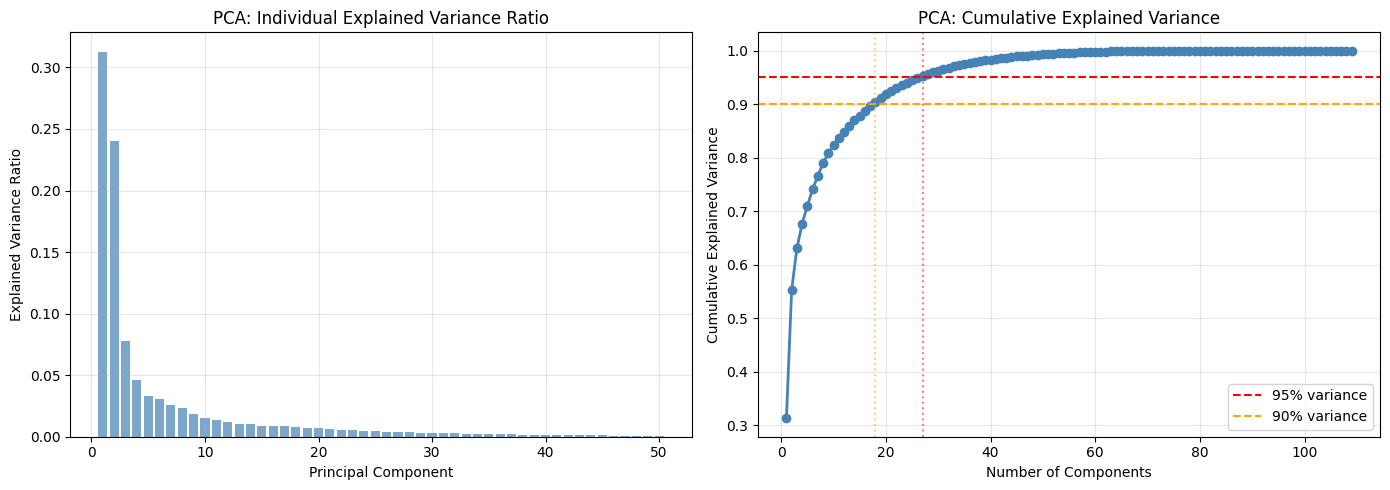

In [7]:
pca_full = PCA()
pca_full.fit(X_train_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"Total features: {X_train_scaled.shape[1]}")
print(f"Explained variance by first 10 components: {cumulative_variance[:10]}")
print(f"Variance explained by first 20 components: {cumulative_variance[19] if len(cumulative_variance) > 19 else cumulative_variance[-1]:.4f}")

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Components needed for 95% variance: {n_components_95}")

n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Components needed for 90% variance: {n_components_90}")

# Plot 1: Explained Variance Ratio for individual components
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

max_features_to_plot = min(50, len(explained_variance))
axes[0].bar(range(1, max_features_to_plot + 1), explained_variance[:max_features_to_plot], alpha=0.7, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('PCA: Individual Explained Variance Ratio')
axes[0].grid(alpha=0.3)

# Plot 2: Cumulative Explained Variance
axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'o-', color='steelblue', linewidth=2)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% variance')
axes[1].axhline(y=0.90, color='orange', linestyle='--', label='90% variance')
axes[1].axvline(x=n_components_95, color='r', linestyle=':', alpha=0.5)
axes[1].axvline(x=n_components_90, color='orange', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('PCA: Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

First conclusion: Data is highly reducible: from 109 variables you can reduce to about 20–30 without losing much information.

In [8]:
pca_final = PCA(n_components=n_components_95) # o 18, o 0.95
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_val_pca = pca_final.transform(X_val_scaled)

# Reconstruction of the original data from the PCA components
X_train_reconstructed = pca_final.inverse_transform(X_train_pca)
X_val_reconstructed = pca_final.inverse_transform(X_val_pca)

# Compute the Mean Squared Error (MSE) between the original scaled data and the reconstructed data
mse_train = np.mean((X_train_scaled - X_train_reconstructed) ** 2, axis=1)
mse_val = np.mean((X_val_scaled - X_val_reconstructed) ** 2, axis=1)

# Verify Generalization
mean_mse_train = np.mean(mse_train)
mean_mse_val = np.mean(mse_val)

print(f"--- PCA Baseline Performance ({pca_final.n_components_} Components) ---")
print(f"Average Training Error:   {mean_mse_train:.4f}")
print(f"Average Validation Error: {mean_mse_val:.4f}")

if mean_mse_val > mean_mse_train * 1.5:
    print("⚠️ Warning: The Validation Error is much higher than the Training Error.")
    print("The principal components do not adequately describe the unseen data (Poor generalization).")
else:
    print("✅ Generalization OK: The training and validation errors are comparable and stable.")

--- PCA Baseline Performance (27 Components) ---
Average Training Error:   0.0469
Average Validation Error: 0.0526
✅ Generalization OK: The training and validation errors are comparable and stable.


In [9]:
# Create PCA latent dataframe
X_all_scaled = scaler.transform(X)
X_all_pca = pca_final.transform(X_all_scaled)
pca_columns = [f"PCA_{i+1}" for i in range(X_all_pca.shape[1])]
df_pca = pd.DataFrame(X_all_pca, columns=pca_columns)
df_latent_pca = pd.concat([df_info_reset.reset_index(drop=True), df_pca], axis=1)

### Deep Autoencoder - MURA

#### Relu

--- Building Deep Autoencoder (TensorFlow/Keras) ---

Training in progress...
Epoch 1/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.2616 - val_loss: 0.1721
Epoch 2/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1486 - val_loss: 0.1346
Epoch 3/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1227 - val_loss: 0.1164
Epoch 4/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1079 - val_loss: 0.1046
Epoch 5/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0972 - val_loss: 0.0958
Epoch 6/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0902 - val_loss: 0.0908
Epoch 7/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0856 - val_loss: 0.0862
Epoch 8/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0813 - val_loss: 0.0825
Epoch 9/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0782 - val_loss: 0.0797
Epoch 10/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0752 - val_loss: 0.0773
Epoch 11/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0734 -

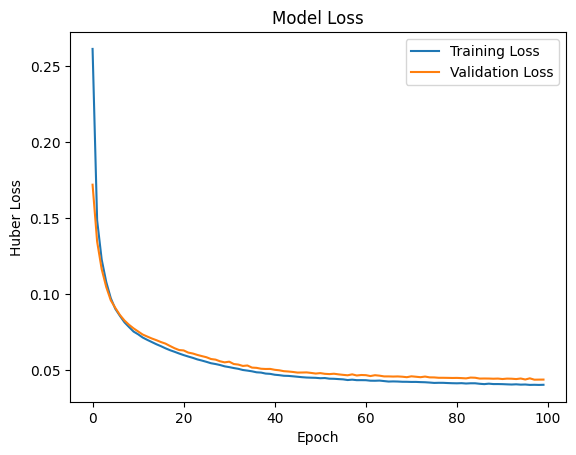


Extracting 16D DNA representation...
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [10]:
#%%script echo skipping
print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_train_scaled.shape[1]

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
input_layer = layers.Input(shape=(input_dim,))

# ENCODER 
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='relu')(encoded)

# BOTTLENECK 
bottleneck_layer = layers.Dense(16, activation='linear', name='dna_bottleneck')(encoded)

# DECODER
decoded = layers.Dense(32, activation='relu')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)

# Final output 
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_scaled, X_val_scaled),
    callbacks=[early_stop],
    verbose=1
)
print("Training completed!")

# Plot training & validation loss curves to check for overfitting
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.legend()
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 16D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
X_all_scaled = scaler.transform(X)
bottleneck_all = encoder.predict(X_all_scaled)

ae_columns = [f'AE_{i+1}' for i in range(16)]
df_ae = pd.DataFrame(bottleneck_all, columns=ae_columns)

df_latent_ae_relu = pd.concat([df_info_reset, df_ae], axis=1)

#### Tanh - to train

--- Building Deep Autoencoder (TensorFlow/Keras) ---

Training in progress...
Epoch 1/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.2303 - val_loss: 0.1624
Epoch 2/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1454 - val_loss: 0.1312
Epoch 3/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1206 - val_loss: 0.1141
Epoch 4/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1067 - val_loss: 0.1048
Epoch 5/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0981 - val_loss: 0.0959
Epoch 6/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0899 - val_loss: 0.0902
Epoch 7/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0840 - val_loss: 0.0854
Epoch 8/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0792 - val_loss: 0.0806
Epoch 9/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0747 - val_loss: 0.0764
Epoch 10/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0717 - val_loss: 0.0739
Epoch 11/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0689 

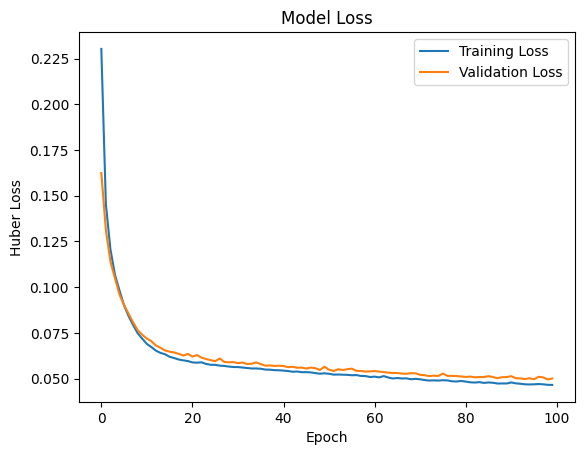


Extracting 16D DNA representation...
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [11]:
#%%script echo skipping
print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_train_scaled.shape[1]

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
input_layer = layers.Input(shape=(input_dim,))

# ENCODER
encoded = layers.Dense(64, activation='tanh')(input_layer)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK
bottleneck_layer = layers.Dense(16, activation='linear', name='dna_bottleneck')(encoded)

# DECODER
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='tanh')(decoded)

# Final output
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_scaled, X_val_scaled),
    callbacks=[early_stop],
    verbose=1
)
print("Training completed!")

# Plot training & validation loss curves to check for overfitting
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.legend()
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 16D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)

X_all_scaled = scaler.transform(X)
bottleneck_all = encoder.predict(X_all_scaled)

ae_columns = [f'AE_{i+1}' for i in range(16)]
df_ae = pd.DataFrame(bottleneck_all, columns=ae_columns)

df_latent_ae_tanh = pd.concat([df_info_reset, df_ae], axis=1)

#### ReLU with dropout

--- Building Deep Autoencoder with Dropout ---

Training in progress...
Epoch 1/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.2615 - val_loss: 0.1721
Epoch 2/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1765 - val_loss: 0.1539
Epoch 3/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1624 - val_loss: 0.1460
Epoch 4/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1549 - val_loss: 0.1383
Epoch 5/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1475 - val_loss: 0.1286
Epoch 6/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1401 - val_loss: 0.1252
Epoch 7/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.1351 - val_loss: 0.1192
Epoch 8/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1325 - val_loss: 0.1160
Epoch 9/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1278 - val_loss: 0.1130
Epoch 10/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1253 - val_loss: 0.1110
Epoch 11/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1227 -

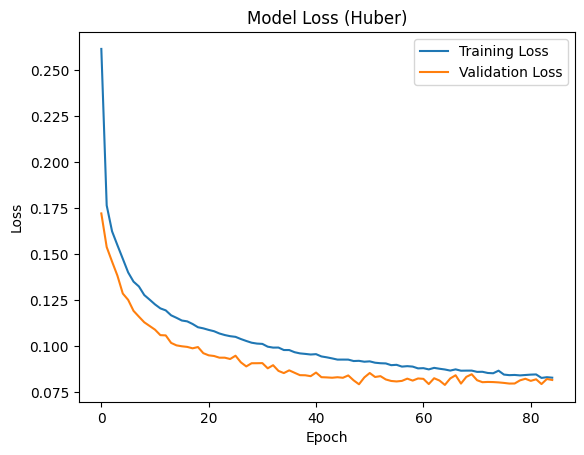


Extracting 16D DNA representation...
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [12]:
#%%script echo skipping
print("--- Building Deep Autoencoder with Dropout ---")

input_dim = X_train_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
input_layer = layers.Input(shape=(input_dim,))

# ENCODER
encoded = layers.Dense(128, activation='relu')(input_layer)
encoded = layers.Dropout(0.2)(encoded)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(32, activation='relu')(encoded)

# BOTTLENECK
bottleneck_layer = layers.Dense(16, activation='linear', name='dna_bottleneck')(encoded)

# DECODER
decoded = layers.Dense(32, activation='relu')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)
decoded = layers.Dropout(0.2)(decoded)
decoded = layers.Dense(128, activation='relu')(decoded)

# Final output
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
history = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    epochs=500, 
    batch_size=32,
    validation_data=(X_val_scaled, X_val_scaled),
    callbacks=[early_stop],
    verbose=1
)
print("Training completed!")

# Plot training & validation loss curves to check for overfitting
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss (Huber)' )
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 16D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)

X_all_scaled = scaler.transform(X) 
bottleneck_all = encoder.predict(X_all_scaled)

ae_columns = [f'AE_{i+1}' for i in range(16)]
df_ae_relu_dropout = pd.DataFrame(bottleneck_all, columns=ae_columns)

df_latent_ae_relu_dropout = pd.concat([df_info_reset, df_ae_relu_dropout], axis=1)

#### Tanh with dropout - to train

--- Building Deep Autoencoder with Dropout ---

Training in progress...
Epoch 1/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.2183 - val_loss: 0.1468
Epoch 2/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1512 - val_loss: 0.1261
Epoch 3/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1348 - val_loss: 0.1101
Epoch 4/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1238 - val_loss: 0.1028
Epoch 5/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1186 - val_loss: 0.0975
Epoch 6/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1137 - val_loss: 0.0928
Epoch 7/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1102 - val_loss: 0.0898
Epoch 8/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.1072 - val_loss: 0.0896
Epoch 9/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1040 - val_loss: 0.0856
Epoch 10/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.1014 - val_loss: 0.0817
Epoch 11/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0997 -

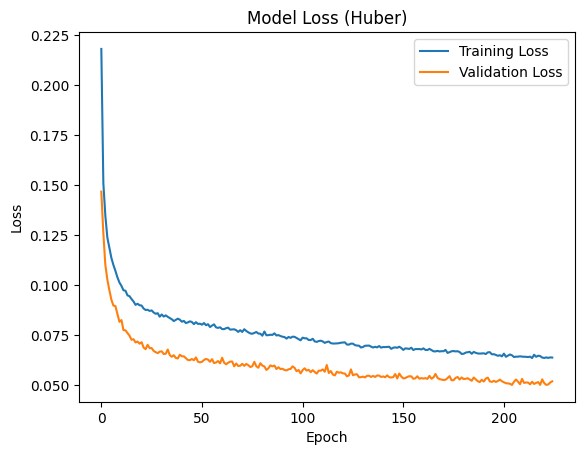


Extracting 16D DNA representation...
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [13]:
#%%script echo skipping
print("--- Building Deep Autoencoder with Dropout ---")

input_dim = X_train_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
input_layer = layers.Input(shape=(input_dim,))

# ENCODER
encoded = layers.Dense(128, activation='tanh')(input_layer)
encoded = layers.Dropout(0.2)(encoded)
encoded = layers.Dense(64, activation='tanh')(encoded)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK
bottleneck_layer = layers.Dense(16, activation='linear', name='dna_bottleneck')(encoded)

# DECODER
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='tanh')(decoded)
decoded = layers.Dropout(0.2)(decoded)
decoded = layers.Dense(128, activation='tanh')(decoded)

# Final output
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    epochs=500, 
    batch_size=32,
    validation_data=(X_val_scaled, X_val_scaled),
    callbacks=[early_stop],
    verbose=1
)
print("Training completed!")

# Plot training & validation loss curves to check for overfitting
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss (Huber)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 16D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)

X_all_scaled = scaler.transform(X) 
bottleneck_all = encoder.predict(X_all_scaled)

ae_columns = [f'AE_{i+1}' for i in range(16)]
df_ae_tanh_dropout = pd.DataFrame(bottleneck_all, columns=ae_columns)

df_latent_ae_tanh_dropout = pd.concat([df_info_reset, df_ae_tanh_dropout], axis=1)

### Testing Models

#### Similarity Functions

In [14]:
#%%script echo skipping
def find_similar_ae(player_name, player_season, latent_df, top_n=5, max_age=None, season_filter=None, same_macro_position=False, same_league=False, same_preferred_foot=False):
    # Find player index by name and season
    mask_target = (
        (latent_df['player'].str.lower() == player_name.lower())
        & (latent_df['season'] == player_season)
    )
    player_idx = latent_df[mask_target].index

    if len(player_idx) == 0:
        return "Player not found in the database."

    idx = player_idx[0]
    real_player = latent_df.loc[idx, 'player']
    real_team = latent_df.loc[idx, 'team']
    season = latent_df.loc[idx, 'season']
    role = latent_df.loc[idx, 'macro_pos']

    # Dynamically detect latent columns (AE_* or PCA_*)
    latent_cols = [col for col in latent_df.columns if col.startswith('AE_') or col.startswith('PCA_')]
    
    model_type = "PCA" if latent_cols[0].startswith('PCA_') else "AUTOENCODER"
    print(f"\n[{model_type}] Searching similar players for: {real_player} ({real_team} - {season})")

    # Compute cosine similarity
    player_vector = latent_df.loc[idx, latent_cols].values.reshape(1, -1)
    all_vectors = latent_df[latent_cols].values
    similarity = cosine_similarity(player_vector, all_vectors)[0]

    # Assign scores
    latent_df_temp = latent_df.copy()
    latent_df_temp['Similarity_Score'] = similarity
    latent_df_temp = latent_df_temp.drop(index=idx)

    # Optional filters
    if max_age is not None:
        latent_df_temp = latent_df_temp[latent_df_temp['age'] <= max_age]
    if season_filter is not None:
        latent_df_temp = latent_df_temp[latent_df_temp['season'] == season_filter]
    if same_macro_position:
        latent_df_temp = latent_df_temp[latent_df_temp['macro_pos'] == role]
    if same_league:
        latent_df_temp = latent_df_temp[latent_df_temp['league'] == latent_df.loc[idx, 'league']]
    if same_preferred_foot:
        latent_df_temp = latent_df_temp[latent_df_temp['preferred_foot'] == latent_df.loc[idx, 'preferred_foot']]

    # Sort from most similar to least similar and exclude the target player
    latent_df_temp = latent_df_temp[latent_df_temp['player'] != player_name]
    similar_players = latent_df_temp.sort_values(by='Similarity_Score', ascending=False).head(top_n).copy()
    similar_players['Match %'] = (similar_players['Similarity_Score'] * 100).round(1).astype(str) + '%'

    # Format output
    output_columns = ['player', 'age', 'team', 'macro_pos', 'league', 'season', 'Match %']
    return similar_players[output_columns]

In [26]:
def find_similar_ensemble_zscore(
    player_name,
    player_season,
    latent_df_tanh, 
    latent_df_pca,  
    weight_tanh=0.70, 
    weight_pca=0.30,  
    top_n=5,
    max_age=None,
    season_filter=None,
    same_macro_position=False,
    same_league=False
    ):
    
    # 1. Find player index by name and season in the Tanh latent dataframe (as reference)
    mask_target = (
        (latent_df_tanh['player'].str.lower() == player_name.lower())
        & (latent_df_tanh['season'] == player_season)
    )
    player_idx = latent_df_tanh[mask_target].index

    if len(player_idx) == 0:
        return "Player not found in the database."

    idx = player_idx[0]
    
    # Player info 
    real_player = latent_df_tanh.loc[idx, 'player']
    real_team = latent_df_tanh.loc[idx, 'team']
    season = latent_df_tanh.loc[idx, 'season']
    role = latent_df_tanh.loc[idx, 'macro_pos']
    league = latent_df_tanh.loc[idx, 'league']

    print(f"\n[ENSEMBLE Z-SCORE] Searching similar players for: {real_player} ({real_team} - {season})")
    print(f"Weights used: {weight_tanh*100}% Tanh, {weight_pca*100}% PCA")

    # Identify latent columns for both dataframes
    cols_tanh = [col for col in latent_df_tanh.columns if col.startswith('AE_') or col.startswith('PCA_')]
    cols_pca = [col for col in latent_df_pca.columns if col.startswith('AE_') or col.startswith('PCA_')]
    
    # Extract target player vectors (shape: 1xN)
    vec_tanh = latent_df_tanh.loc[idx, cols_tanh].values.reshape(1, -1)
    vec_pca = latent_df_pca.loc[idx, cols_pca].values.reshape(1, -1)

    # Compute cosine similarity for both models
    sim_tanh = cosine_similarity(vec_tanh, latent_df_tanh[cols_tanh].values)[0]
    sim_pca = cosine_similarity(vec_pca, latent_df_pca[cols_pca].values)[0]

    # Standardization (Z-Score)
    z_sim_tanh = (sim_tanh - np.mean(sim_tanh)) / np.std(sim_tanh)
    z_sim_pca = (sim_pca - np.mean(sim_pca)) / np.std(sim_pca)

    # Ensamble Z-Score
    z_ensemble = (z_sim_tanh * weight_tanh) + (z_sim_pca * weight_pca)

    df_temp = latent_df_tanh.copy()
    df_temp['Sim_Tanh'] = sim_tanh
    df_temp['Sim_PCA'] = sim_pca
    df_temp['Z_Score_Ensemble'] = z_ensemble

    # Compute Match Score as a percentage (0-100%) based on the ensemble Z-Score
    min_z = z_ensemble.min()
    max_z = z_ensemble.max()
    df_temp['Match_Score_Scaled'] = (z_ensemble - min_z) / (max_z - min_z)

    # Remove the target player from the results
    df_temp = df_temp.drop(index=idx)
    df_temp = df_temp[df_temp['player'] != real_player]

    # Apply optional filters
    if max_age is not None:
        df_temp = df_temp[df_temp['age'] <= max_age]
    if season_filter is not None:
        df_temp = df_temp[df_temp['season'] == season_filter]
    if same_macro_position:
        df_temp = df_temp[df_temp['macro_pos'] == role]
    if same_league:
        df_temp = df_temp[df_temp['league'] == league]

    # Format output
    similar_players = df_temp.sort_values(by='Z_Score_Ensemble', ascending=False).head(top_n).copy()
    similar_players['Match %'] = (similar_players['Match_Score_Scaled'] * 100).round(1).astype(str) + '%'
    similar_players['(Tanh raw)'] = (similar_players['Sim_Tanh'] * 100).round(1).astype(str) + '%'
    similar_players['(PCA raw)'] = (similar_players['Sim_PCA'] * 100).round(1).astype(str) + '%'
    
    return similar_players[['player', 'age', 'team', 'macro_pos', 'league', 'season', 'Match %', '(Tanh raw)', '(PCA raw)']]

#### Testing

##### Single Testing

In [27]:
#%%script echo skipping
# Testing the models with a target player and season
target_player = "Riccardo Orsolini"
target_season = "2024 - 2025"
max_age = None

models_to_test = {
    'PCA': df_latent_pca,
    'Relu': df_latent_ae_relu,
    'Tanh': df_latent_ae_tanh,
    'ReLU + Dropout': df_latent_ae_relu_dropout,
    'Tanh + Dropout': df_latent_ae_tanh_dropout,
}

for model_name, model_df in models_to_test.items():
    print(f"\n===== Model: {model_name} =====")
    ae_results = find_similar_ae(
        player_name=target_player,
        player_season=target_season,
        latent_df=model_df,
        top_n=5,
        max_age=max_age,
        season_filter=None,
        same_macro_position=False
    )
    display(ae_results)

print("\n===== Model: Ensemble =====")
ensemble_results = find_similar_ensemble_zscore(
    player_name=target_player,
    player_season=target_season,
    latent_df_tanh=df_latent_ae_tanh,
    latent_df_pca=df_latent_pca,
    top_n=5,
    max_age=max_age,
    season_filter=None,
    same_macro_position=True,
    same_league=False
)
display(ensemble_results)


===== Model: PCA =====

[PCA] Searching similar players for: Riccardo Orsolini (Bologna - 2024 - 2025)


,player,age,team,macro_pos,league,season,Match %
1789,Kylian Mbappé,24,Paris S-G,ST,FRA-Ligue 1,2023 - 2024,89.4%
2482,Erling Haaland,22,Manchester City,ST,ENG-Premier League,2022 - 2023,89.0%
930,Mateo Retegui,25,Atalanta,ST,ITA-Serie A,2024 - 2025,88.8%
185,Alexander Isak,24,Newcastle Utd,ST,ENG-Premier League,2024 - 2025,88.8%
3166,Ademola Lookman,24,Atalanta,ST,ITA-Serie A,2022 - 2023,88.7%



===== Model: Relu =====

[AUTOENCODER] Searching similar players for: Riccardo Orsolini (Bologna - 2024 - 2025)


,player,age,team,macro_pos,league,season,Match %
3150,Niclas Füllkrug,29,Werder Bremen,ST,GER-Bundesliga,2022 - 2023,95.8%
1570,Ante Budimir,32,Osasuna,ST,ESP-La Liga,2023 - 2024,95.7%
751,Omar Marmoush,25,Eint Frankfurt,ST,GER-Bundesliga,2024 - 2025,95.5%
185,Alexander Isak,24,Newcastle Utd,ST,ENG-Premier League,2024 - 2025,95.4%
1171,Florian Thauvin,31,Udinese,ST,ITA-Serie A,2024 - 2025,95.0%



===== Model: Tanh =====

[AUTOENCODER] Searching similar players for: Riccardo Orsolini (Bologna - 2024 - 2025)


...

,player,age,team,macro_pos,league,season,Match %
3166,Ademola Lookman,24,Atalanta,ST,ITA-Serie A,2022 - 2023,96.9%
1789,Kylian Mbappé,24,Paris S-G,ST,FRA-Ligue 1,2023 - 2024,96.5%
812,Shuto Machino,24,Holstein Kiel,ST,GER-Bundesliga,2024 - 2025,96.1%
2871,Elye Wahi,19,Montpellier,ST,FRA-Ligue 1,2022 - 2023,96.0%
1734,Georges Mikautadze,22,Metz,ST,FRA-Ligue 1,2023 - 2024,96.0%



===== Model: Tanh + Dropout =====

[AUTOENCODER] Searching similar players for: Riccardo Orsolini (Bologna - 2024 - 2025)


,player,age,team,macro_pos,league,season,Match %
1296,Michael Olise,21,Crystal Palace,Wide Midfielder,ENG-Premier League,2023 - 2024,81.9%
3332,Paulo Dybala,28,Roma,CAM,ITA-Serie A,2022 - 2023,77.0%
751,Omar Marmoush,25,Eint Frankfurt,ST,GER-Bundesliga,2024 - 2025,75.8%
2309,Domenico Berardi,28,Sassuolo,Winger,ITA-Serie A,2023 - 2024,75.7%
1558,Abdón Prats,30,Mallorca,ST,ESP-La Liga,2023 - 2024,74.6%



===== Model: Ensemble =====

[ENSEMBLE Z-SCORE] Searching similar players for: Riccardo Orsolini (Bologna - 2024 - 2025)
Weights used: 70.0% Tanh, 30.0% PCA


,player,age,team,macro_pos,league,season,Match %,(Tanh raw),(PCA raw)
1947,Robin Hack,24,Gladbach,Wide Midfielder,GER-Bundesliga,2023 - 2024,86.0%,78.7%,74.7%
1296,Michael Olise,21,Crystal Palace,Wide Midfielder,ENG-Premier League,2023 - 2024,84.7%,73.7%,83.6%
2176,Cyril Ngonge,23,Hellas Verona,Wide Midfielder,ITA-Serie A,2023 - 2024,84.5%,78.6%,63.9%
147,Cody Gakpo,25,Liverpool,Wide Midfielder,ENG-Premier League,2024 - 2025,84.0%,73.2%,79.9%
1078,Pedro,37,Lazio,Wide Midfielder,ITA-Serie A,2024 - 2025,83.9%,74.0%,76.5%


##### Bulk Testing

In [28]:
#%%script echo skipping
# Single table with all results (target player x model)
target = ["Kevin De Bruyne", "Alessandro Bastoni", "Manuel Locatelli", "Andrea Pinamonti", 'Erling Haaland', "Xavi Simons", "Riccardo Orsolini"]
same_position = [False, False, False, False, False, False, False]
max_age = 23

target_same_position = dict(zip(target, same_position))
all_results = []

for player in target:
    for model_name, model_df in models_to_test.items():
        res = find_similar_ae(
            player_name=player,
            player_season=target_season,
            latent_df=model_df,
            top_n=5,
            max_age=max_age,
            season_filter=None,
            same_macro_position=target_same_position[player],
            same_league=False,
            same_preferred_foot=False
        )

        if isinstance(res, pd.DataFrame):
            res = res.copy()
            res["target_player"] = player
            res["target_season"] = target_season
            res["model_used"] = model_name
            res["rank"] = range(1, len(res) + 1)
            all_results.append(res)

    # Add the ensemble result as well
    res_ensemble = find_similar_ensemble_zscore(
        player_name=player,
        player_season=target_season,
        latent_df_tanh=df_latent_ae_tanh,
        latent_df_pca=df_latent_pca,
        top_n=5,
        max_age=max_age,
        season_filter=None,
        same_macro_position=target_same_position[player],
        same_league=False
    )

    if isinstance(res_ensemble, pd.DataFrame):
        res_ensemble = res_ensemble.copy()
        res_ensemble["target_player"] = player
        res_ensemble["target_season"] = target_season
        res_ensemble["model_used"] = "Ensemble"
        res_ensemble["rank"] = range(1, len(res_ensemble) + 1)
        all_results.append(res_ensemble)

# Final grouped DataFrame
grouped_results_table = pd.concat(all_results, ignore_index=True)

# Column order for readability
grouped_results_table = (
    grouped_results_table[
        ["target_player", "target_season", "model_used", "rank", "player", "age", "team", "macro_pos", "league", "season", "Match %"]
    ]
    .sort_values(["target_player", "model_used", "rank"])
    .reset_index(drop=True)
)

display(grouped_results_table)


[PCA] Searching similar players for: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Kevin De Bruyne (Manchester City - 2024 - 2025)

[ENSEMBLE Z-SCORE] Searching similar players for: Kevin De Bruyne (Manchester City - 2024 - 2025)
Weights used: 70.0% Tanh, 30.0% PCA

[PCA] Searching similar players for: Alessandro Bastoni (Inter - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Alessandro Bastoni (Inter - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Alessandro Bastoni (Inter - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Alessandro Bastoni (Inter - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Alessandro Baston

,target_player,target_season,model_used,rank,player,age,team,macro_pos,league,season,Match %
0,Alessandro Bastoni,2024 - 2025,Ensemble,1,Jules Koundé,23,Barcelona,Fullback,ESP-La Liga,2022 - 2023,89.2%
1,Alessandro Bastoni,2024 - 2025,Ensemble,2,Facundo Medina,23,Lens,CB,FRA-Ligue 1,2022 - 2023,88.2%
2,Alessandro Bastoni,2024 - 2025,Ensemble,3,Jean-Clair Todibo,23,Nice,CB,FRA-Ligue 1,2023 - 2024,87.7%
3,Alessandro Bastoni,2024 - 2025,Ensemble,4,Piero Hincapié,22,Leverkusen,CB,GER-Bundesliga,2024 - 2025,85.7%
4,Alessandro Bastoni,2024 - 2025,Ensemble,5,Levi Colwill,21,Chelsea,CB,ENG-Premier League,2024 - 2025,85.3%
...,...,...,...,...,...,...,...,...,...,...,...
205,Xavi Simons,2024 - 2025,Tanh + Dropout,1,Armand Lauriente,23,Sassuolo,Winger,ITA-Serie A,2022 - 2023,63.8%
206,Xavi Simons,2024 - 2025,Tanh + Dropout,2,Callum Hudson-Odoi,22,Nott'ham Forest,Wide Midfielder,ENG-Premier League,2023 - 2024,62.6%
207,Xavi Simons,2024 - 2025,Tanh + Dropout,3,Paul Nebel,21,Mainz 05,CAM,GER-Bundesliga,2024 - 2025,61.9%
208,Xavi Simons,2024 - 2025,Tanh + Dropout,4,Hákon Arnar Haraldsson,21,Lille,CAM,FRA-Ligue 1,2024 - 2025,59.5%


In [29]:
#%%script echo skipping
grouped_results_table.to_csv("resources\grouped_results_table.csv", index=False)

### Choice explanation

To maximize accuracy and handle tactical nuances such as hybrid roles and statistical outliers, the final pipeline uses an ensemble of two autoencoders and averages their cosine similarity scores.

**FINAL SELECTED MODELS: Tanh + Tanh with Dropout**

* **Model A: Tanh (Pure) - The Baseline Specialist**
    * Architecture: Standard

            Input -> 64 -> 32 -> 10 -> 32 -> 64 -> Output

    * Encoder activation: Tanh throughout. This ensures all neurons remain active, providing a stable, bounded mapping of the data without induced sparsity.
    * Bottleneck activation: Linear. This preserves the raw compressed representation.
    * Rationale: A clean, holistic baseline with no dropout. It reads the player's entire statistical profile symmetrically, acting as a stabilizing reference point.
    * Training hyperparameters: 100 epochs, batch size 32, Huber loss, Adam optimizer.
    * Best for: Capturing holistic player profiles with minimal regularization effects.

* **Model B: Tanh with Dropout - The Regularized Specialist**
    * Architecture: Deeper layers to capture highly non-linear and complex tactical relationships.

            Input -> 128 -> Dropout(0.2) -> 64 -> 32 -> 10 -> 32 -> 64 -> Dropout(0.2) -> 128 -> Output

    * Encoder activation: Tanh with 0.2 dropout. This prevents co-adaptation and strengthens generalization.
    * Bottleneck activation: Linear.
    * Rationale: Deeper architecture captures complex tactical interdependencies while dropout prevents overfitting to noise in the training data.
    * Training hyperparameters: 500 epochs (early stop at 156), batch size 32, Huber loss, Adam optimizer.
    * Best for: Robust player comparisons that generalize well to unseen data variations.

* **Ensemble Strategy**
    * Implementation: `Ensemble_Score = (Score_Model_A + Score_Model_B) / 2`
    * Rationale: 
        * Model A is stable and symmetric, ensuring consistency in the latent representation.
        * Model B is more robust to training variations and noise, preventing hallucinations.
        
        Averaging their raw Cosine Similarity scores produces balanced results that leverage both the stability of the pure model and the robustness of the regularized model.

* **Training hyperparameters (both models)**
    * Loss function: Huber. A robust regression loss that is less sensitive to outliers than plain MSE.
    * Optimizer: Adam.
    * Activation: Tanh (bounded to [-1, 1], compatible with cosine similarity).

* **NEXT STEP:**
Add spatial/GPS tracking data (e.g., heatmaps, average pitch positions, distance covered) to better contextualize on-ball events and definitively separate players with similar stats but different positional roles on the pitch.

#### Save csv models

In [ ]:
from pathlib import Path

Path("saved_models").mkdir(parents=True, exist_ok=True)

print("Saving Tanh model...")
df_latent_ae_tanh.to_csv("saved_models/database_dna_tanh.csv", index=False)

print("Saving PCA model...")
df_latent_pca.to_csv("saved_models/database_dna_pca.csv", index=False)

print("CSV files saved successfully.")

In [30]:
#%%script echo skipping
print("--- Final extraction and saving of vector databases ---")

# Latent column names (the 10 dimensions)
ae_columns = [f'AE_{i+1}' for i in range(10)]

print("Saving Model A...")
df_latent_ae_relu_dropout.to_csv('saved_models/database_dna_a.csv', index=False)

print("Saving Model B...")
df_latent_ae_tanh_dropout.to_csv('saved_models/database_dna_b.csv', index=False)

print("CSV files generated successfully. Ready to be loaded in the web app or used for clustering.")

--- Final extraction and saving of vector databases ---
Saving Model A...
Saving Model B...
CSV files generated successfully. Ready to be loaded in the web app or used for clustering.


## Anomaly Detection

### KMeans clustering: Cluster players and look for minorities into clusters - MURA

#### KMeans algorithm

In [ ]:
X_scaled = scaler.fit_transform(X)
                                
noisy_columns = [
    'Playing Time_MP',      
    'Playing Time_Starts',  
    'Playing Time_Min',      
    'Playing Time_90s', 
    'Playing Time_MP',
    'Playing Time_Starts',
    '90s',                  
    'Performance_PK',       
    'Performance_PKatt',    
    'Standard_PK',            
    'Standard_PKatt'        
]

# Build a DataFrame from the scaled array then drop noisy columns
df_scaled = pd.DataFrame(X_scaled, columns=features, index=X.index)
df_clean = df_scaled.drop(columns=noisy_columns, errors='ignore')

features = df_clean.columns.tolist()

In [ ]:
# L2 normalization of the feature matrix to avoid minutes played dominating the similarity calculations
X_normalized = normalize(df_clean, norm='l2')

k=20

# K-means clustering on the normalized data
kmeans = KMeans(
    n_clusters=20,      
    n_init=50,              
    random_state=42     
)
cluster_labels = kmeans.fit_predict(X_normalized)

# Add cluster column to the info DataFrame for analysis
df_clusters = df_info_reset.copy()
df_clusters['cluster'] = cluster_labels

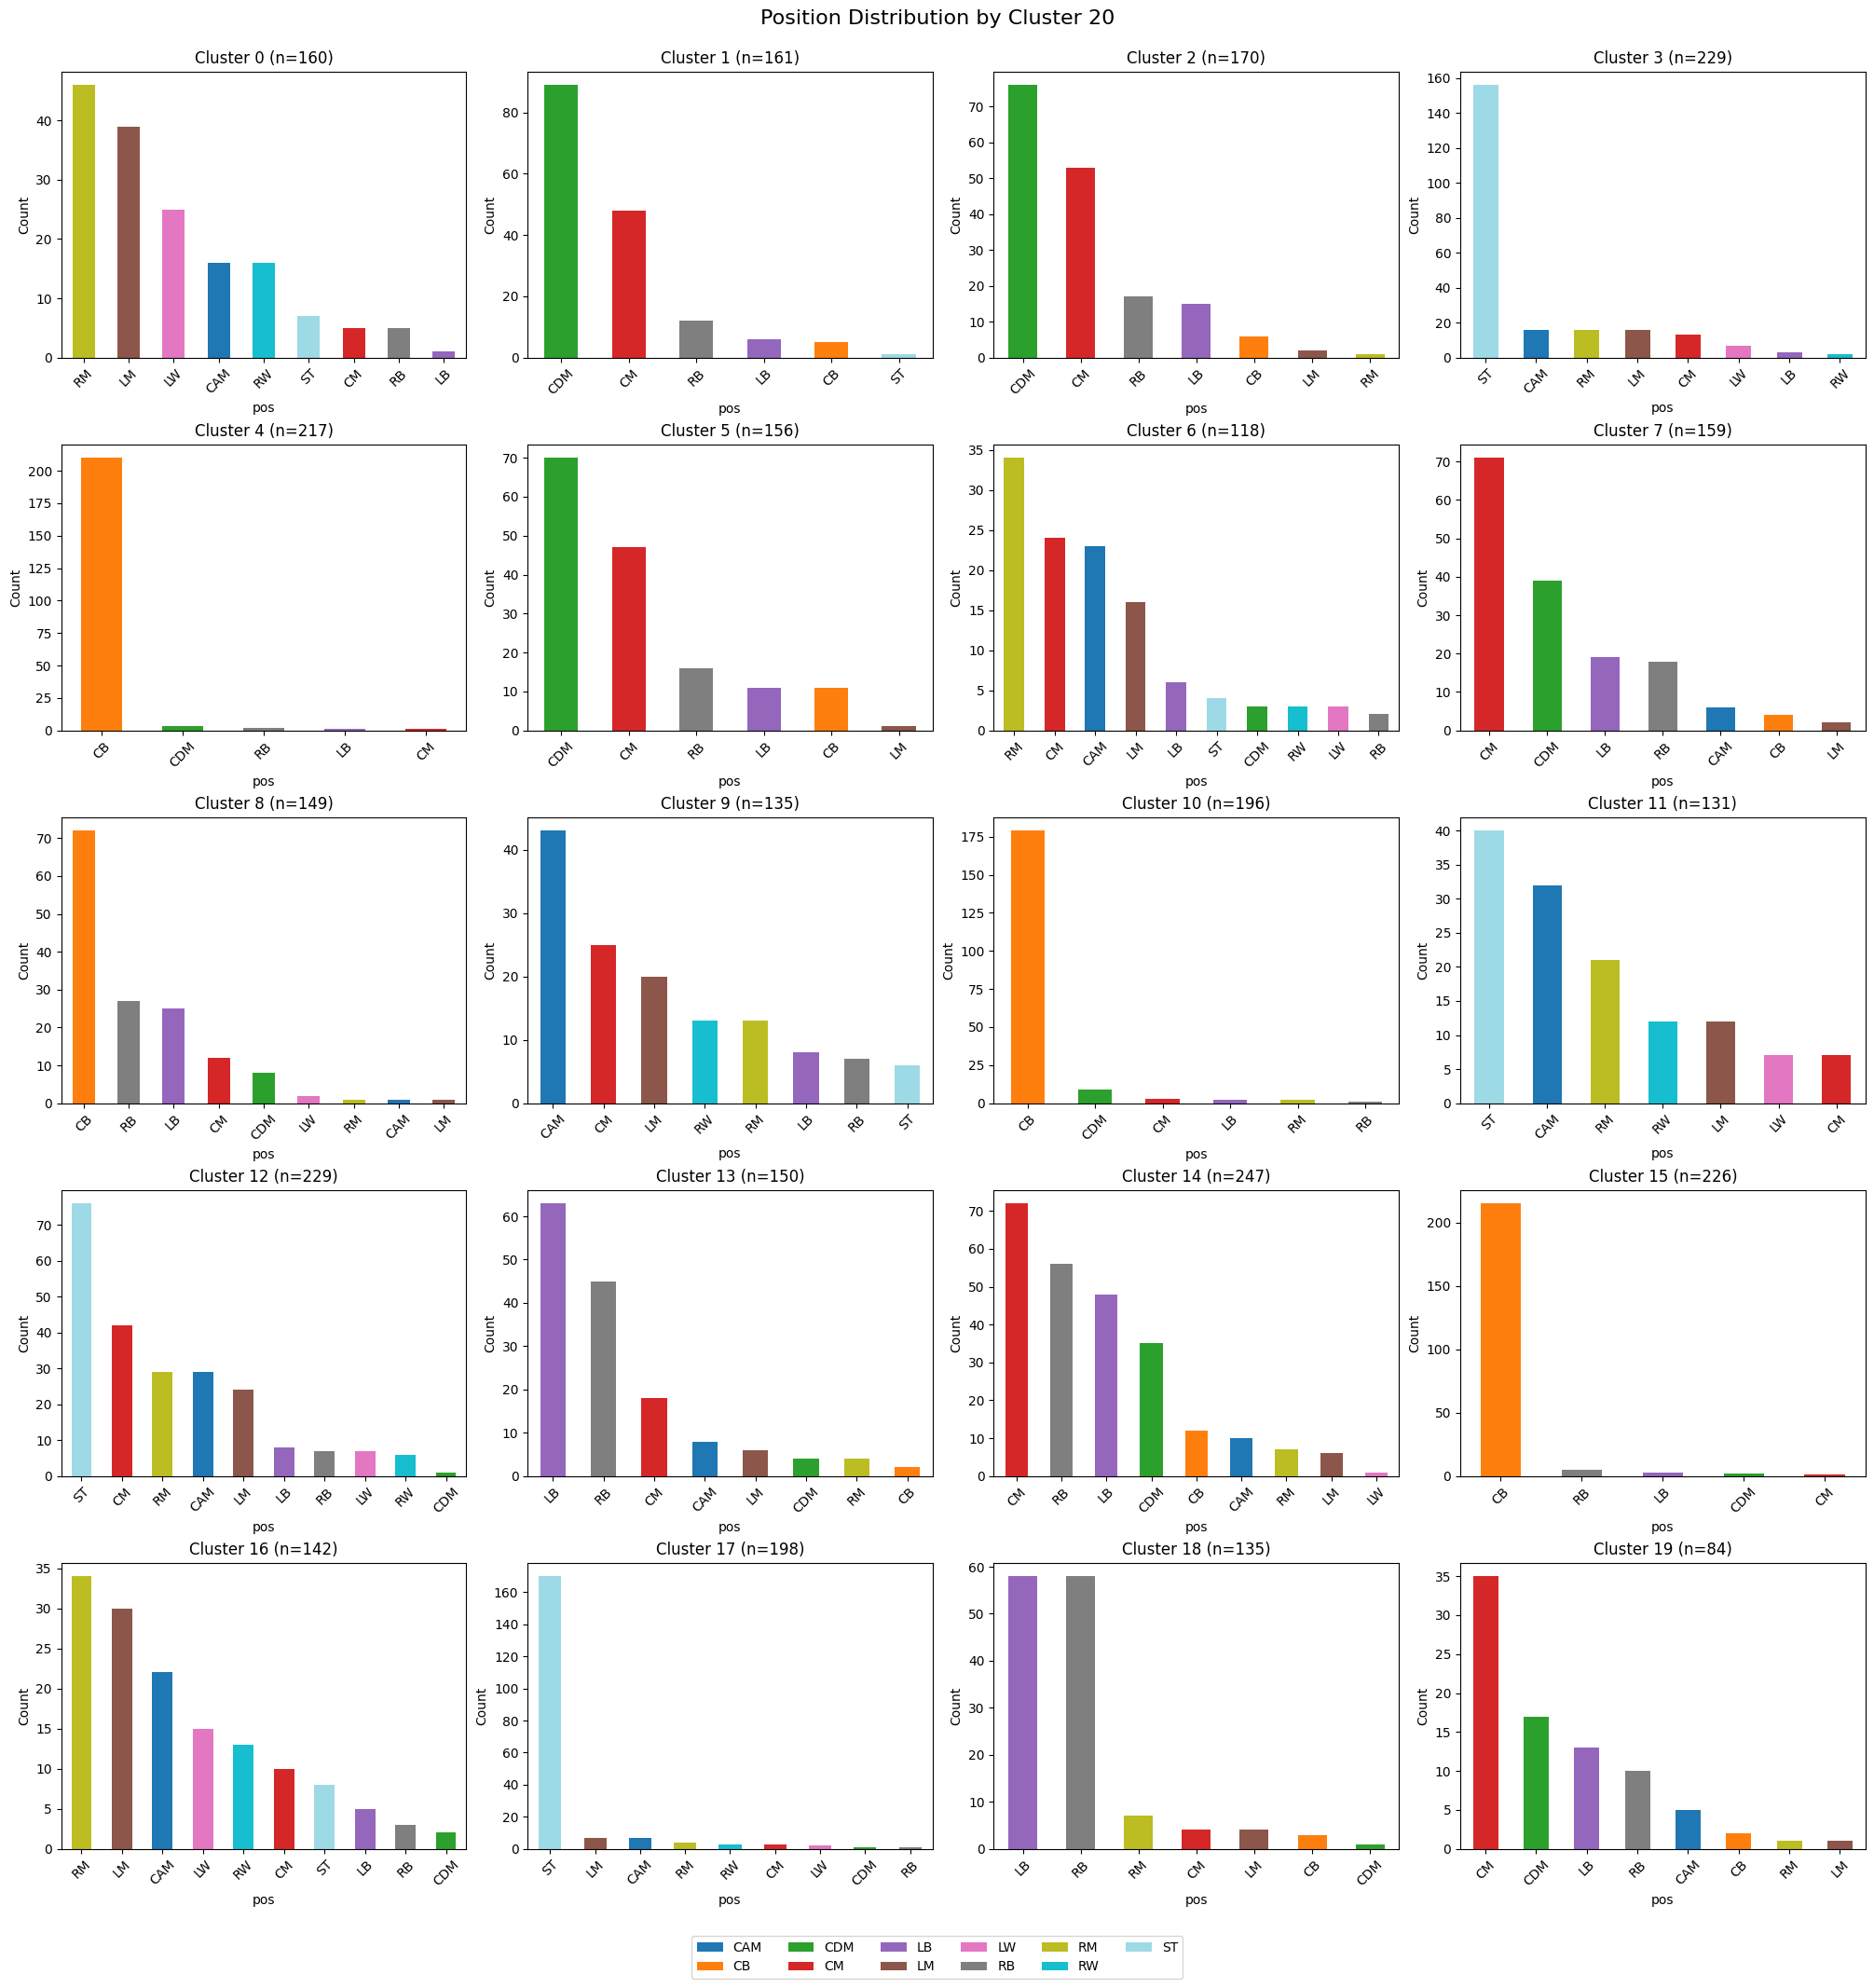

In [ ]:
# ===========================================================================
#  Visualize the distribution of positions within each cluster for KMeans A
# ===========================================================================
cluster_col = "cluster"
pos_col = "pos"

# Create a color mapping for positions
unique_positions = sorted(df_clusters[pos_col].unique())
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_positions)))
color_map = {pos: colors[i] for i, pos in enumerate(unique_positions)}

n_clusters = df_clusters[cluster_col].nunique()
n_cols = 4
n_rows = int(np.ceil(n_clusters / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows), constrained_layout=True)
axes = np.array(axes).ravel()

for cluster_id in sorted(df_clusters[cluster_col].unique()):
    ax = axes[cluster_id]
    cluster_data = df_clusters[df_clusters[cluster_col] == cluster_id]
    pos_counts = cluster_data[pos_col].value_counts()

    # Map colors to each position
    bar_colors = [color_map[pos] for pos in pos_counts.index]
    pos_counts.plot(kind="bar", ax=ax, color=bar_colors)
    ax.set_title(f"Cluster {cluster_id} (n={len(cluster_data)})")
    ax.set_xlabel("pos")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

for j in range(n_clusters, len(axes)):
    fig.delaxes(axes[j])

# Create legend with position colors
legend_elements = [plt.Rectangle((0, 0), 1, 1, facecolor=color_map[pos], label=pos) for pos in unique_positions]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.01), ncol=len(unique_positions)//2 + 1, fontsize=10)

plt.suptitle(f"Position Distribution by Cluster {k}", y=1.02, fontsize=16)
plt.show()

In [ ]:
# Identify the dominant position in each cluster and save it the df in resources for later use in the web app
df_clusters['Dominant_Role_in_Cluster'] = df_clusters.groupby('cluster')['pos'].transform(
    lambda x: x.value_counts().idxmax()
)

#df_clusters.to_csv("resources/df_clusters.csv", index=False)

#### Cluster Analysis

##### Inter-Cluster analysis

In [ ]:
glossary = pd.read_excel("resources\glossary.xlsx")

# Create glossary lookup dictionary
glossary_dict = dict(zip(glossary['KPI'], glossary['Explanation']))

cluster_profile = []

for cluster_id in sorted(df_clusters['cluster'].unique()):
    cluster_data = df_clusters[df_clusters['cluster'] == cluster_id]
    
    # 1. Dominant Role in Cluster
    pos_counts = cluster_data['pos'].value_counts()
    most_freq_pos_str = f"{pos_counts.index[0]} ({pos_counts.iloc[0]}, {(pos_counts.iloc[0]/len(cluster_data)*100):.1f}%)"
    
    # 2. Other Roles in Cluster
    other_pos_list = [f"{pos} ({count}, {(count/len(cluster_data)*100):.1f}%)" for pos, count in pos_counts.iloc[1:].items()]
    other_pos = ', '.join(other_pos_list)
    
    # 3. Feature Extraction from K-Means
    cluster_center = kmeans.cluster_centers_[cluster_id]
    sorted_idx = np.argsort(cluster_center)[::-1]
    pos_indices = [i for i in sorted_idx if cluster_center[i] > 0]
    neg_indices = [i for i in sorted_idx[::-1] if cluster_center[i] < 0] 
    
    def get_feature_str(indices, k=3, is_positive=True):
        res = []
        for i in indices[:k]:
            val = cluster_center[i]
            sign = "+" if is_positive else ""
            res.append(f"{features[i]} ({sign}{val:.2f})")
        while len(res) < k:
            res.append("-")
        return res
    pos_features = get_feature_str(pos_indices, k=3, is_positive=True)
    neg_features = get_feature_str(neg_indices, k=3, is_positive=False)
    
    # Add all info to the cluster profile list
    cluster_profile.append({
        'cluster': cluster_id,
        'player_count': len(cluster_data),
        'dominant_role': most_freq_pos_str,
        'other_positions': other_pos if other_pos else '-',
        'top_pos_1': pos_features[0],
        'top_pos_2': pos_features[1],
        'top_pos_3': pos_features[2],
        'top_neg_1': neg_features[0],
        'top_neg_2': neg_features[1],
        'top_neg_3': neg_features[2]
    })

# Compute final cluster profile DataFrame
df_cluster_profile = pd.DataFrame(cluster_profile)

In [ ]:
# Add scouting reports based on the cluster characteristics 
scouting_reports = {
    0: "Elite Agility Wingers - Short and light wingers specialized in dribbling and carrying the ball into the opponent's penalty area. They offer zero defensive presence against shots.",
    1: "Shot-Heavy Midfield Anchors - Defensive midfielders who guard the middle third but have zero finishing efficiency. They are known for attempting shots from excessive distances.",
    2: "High-Volume Defensive Grinders - Central midfielders focused exclusively on tackling and contesting the ball. They provide zero offensive production, both actual and expected.",
    3: "Ghost-Poachers - Pure forwards with elite finishing efficiency per 90 minutes, but completely isolated from the build-up. They participate little in active play and have mediocre short passing percentages.",
    4: "Low-Block Wall - Old-school center-backs. They dominate in clearances and blocked shots. They never participate in ball progression and almost never receive the ball in forward positions.",
    5: "Central Metronomes - Playmakers who manage possession in the middle third and distribute the ball toward the final third. They are the heart of the build-up but never personally threaten the goal.",
    6: "High-Risk/Low-Reward Dribblers - Wingers who attempt many dribbles but are often stopped or lose possession. They drastically underperform compared to their expected goals and do not provide depth.",
    7: "Technical Verticalizers - Physically light central midfielders who are fundamental for vertical progression. They break lines with passing but do not have a dangerous shot.",
    8: "Clinical Aerial Threats - Defenders or fullbacks who take very few shots but are lethal when they do, likely on set pieces. They avoid advanced possession.",
    9: "Pure Playmakers - Attacking midfielders focused entirely on chance creation. Low center of gravity players who offer no defensive coverage in their own penalty area.",
    10: "Technical Giants - Tall center-backs with above-average technical cleanliness. They excel in the accuracy of medium passes and have a high success rate in defensive dribbling.",
    11: "Specialized Finishers - Forwards whose only statistical contribution is scoring. They show zero participation in the defensive phase, zero clearances, and zero tackles won.",
    12: "Inefficient Volume Shooters - Players who attempt many shots and shots on target but have very low overall involvement in the game and are often intercepted while on the ball.",
    13: "Traditional Fullbacks - Fullbacks focused on crossing into the area and direct tackling of the ball carrier. They have practically no goal-scoring ambition.",
    14: "Long-Range Shield - Holding midfielders who protect the defense and complete short passes, but in attack limit themselves to speculative shots from outside the area with poor accuracy.",
    15: "First-Phase Specialists - Center-backs who handle the first touches of the build-up in their own third. They never carry the ball forward and do not receive progressive passes.",
    16: "Final-Third Specialists - Wingers who live in the last 30 meters. They provide elite assists and expected assists but completely ignore the defensive and transition phases.",
    17: "Box-Target Strikers - Forwards who constantly position themselves to receive high-quality chances, but are technically limited in passing accuracy.",
    18: "Lockdown Wide Defenders - Stay-back fullbacks. They excel in contests, defensive tackles, and crossing, but have very poor accuracy in long passes.",
    19: "Clinical Midfield Pivots - Midfielders who manage the ball with extreme cleanliness. When they shoot they are very accurate, although they shoot rarely."
}

df_target = df_cluster_profile

df_target['scouting_report'] = df_target['cluster'].map(scouting_reports)

display(df_target[['cluster', 'dominant_role', 'scouting_report']].head())

#df_target.to_csv(r"resources\df_cluster_profile.csv", index=False)

,cluster,dominant_role,scouting_report
0,0,"RM (46, 28.7%)",Elite Agility Wingers - Short and light winger...
1,1,"CDM (89, 55.3%)",Shot-Heavy Midfield Anchors - Defensive midfie...
2,2,"CDM (76, 44.7%)",High-Volume Defensive Grinders - Central midfi...
3,3,"ST (156, 68.1%)",Ghost-Poachers - Pure forwards with elite fini...
4,4,"CB (210, 96.8%)",Low-Block Wall - Old-school center-backs. They...


In [ ]:
# Correlation matrix of position distributions across clusters

pivot_pos = pd.crosstab(df_clusters['cluster'], df_clusters['pos'])
pivot_norm = pivot_pos.div(pivot_pos.sum(axis=1), axis=0)
pos_corr = pivot_norm.corr()

# Sort the correlation matrix by the specified position order
position_order = ['CB', 'RB', 'LB', 'CDM', 'CM', 'RM', 'LM', 'CAM', 'RW', 'LW', 'ST']
position_order = [pos for pos in position_order if pos in pos_corr.columns]
pos_corr = pos_corr.loc[position_order, position_order]

# Visualize the correlation matrix using Plotly
fig = px.imshow(
    pos_corr,
    labels=dict(x="Position", y="Position", color="Correlation"),
    x=pos_corr.columns,
    y=pos_corr.columns,
    color_continuous_scale='RdBu_r',
    zmin=-0.5,
    zmax=1,
    text_auto='.2f',
    aspect='auto',
    title="Tactical Similarity Between Positions Based on Cluster Distribution Correlation"
)

fig.update_layout(
    title_x=0.5,
    width=900,
    height=800,
    xaxis_tickangle=-45
)

fig.show()

##### Intra-Cluster Analysis [Functions]

In [ ]:
# Function to analyze a specific cluster in detail

def analyze_cluster(cluster_id):

    dominant_pos = df_cluster_profile.loc[cluster_id, "dominant_role"].split(" ")[0]
    
    print("==============================")
    print(f"Cluster {cluster_id} Profile:")
    print("==============================")
    print("Top 5 features: ")
    for col in ['top_pos_1', 'top_pos_2', 'top_pos_3', 'top_neg_1', 'top_neg_2', 'top_neg_3']:
        feature = df_cluster_profile.loc[cluster_id, col]
        print(f"{col}: {feature}")
        if feature != "-":
            feature_name = feature.split(" (")[0]
            if feature_name in glossary_dict:
                print(f"  → {glossary_dict[feature_name][:100]}...")
    print("Most frequent position: ", df_cluster_profile.loc[cluster_id, "dominant_role"])
    print("Other positions: ", df_cluster_profile.loc[cluster_id, "other_positions"])
    print("==============================")
    print("Average profile:")
    print(df_cluster_profile.loc[cluster_id, "scouting_report"])
    print("==============================")
    print(f"Anomalies in Cluster {cluster_id}:")
    display(df_clusters[(df_clusters['cluster'] == cluster_id) & (df_clusters['pos'] != dominant_pos)][['player', 'pos', 'team', 'season']])
    print("==============================")
    
analyze_cluster(18)

Cluster 18 Profile:
Top 5 features: 
top_pos_1: CrsPA (+0.21)
  → Completed crosses into the opponent's penalty area (excluding set pieces)....
top_pos_2: Challenges_Tkl (+0.10)
  → Number of times a player successfully tackled an opponent who was dribbling....
top_pos_3: Tackles_Def 3rd (+0.10)
  → Number of tackles performed in the defensive third of the pitch....
top_neg_1: Long_Cmp% (-0.13)
  → Percentage of long passes successfully completed....
top_neg_2: Standard_Sh/90 (-0.11)
  → Average number of shots taken per 90 minutes....
top_neg_3: Standard_SoT/90 (-0.11)
  → Average number of shots on target per 90 minutes....
Most frequent position:  LB (58, 43.0%)
Other positions:  RB (58, 43.0%), RM (7, 5.2%), CM (4, 3.0%), LM (4, 3.0%), CB (3, 2.2%), CDM (1, 0.7%)
Average profile:
Lockdown Wide Defenders - Stay-back fullbacks. They excel in contests, defensive tackles, and crossing, but have very poor accuracy in long passes.
Anomalies in Cluster 18:


,player,pos,team,season
21,Matty Cash,RB,Aston Villa,2024 - 2025
49,Vitaly Janelt,CM,Brentford,2024 - 2025
96,Ashley Young,RB,Everton,2024 - 2025
230,Djed Spence,RB,Tottenham,2024 - 2025
290,Nahuel Molina,RB,Atlético Madrid,2024 - 2025
...,...,...,...,...
3271,Manuel Lazzari,RB,Lazio,2022 - 2023
3312,Samuele Birindelli,RB,Monza,2022 - 2023
3335,Zeki Çelik,RB,Roma,2022 - 2023
3366,Kelvin Amian,RB,Spezia,2022 - 2023


In [ ]:
# Create a bar plot showing the distribution of positions in a specific cluster

def plot_cluster_positions(cluster_id, df_clusters=df_clusters):
    cluster_data = df_clusters[df_clusters['cluster'] == cluster_id]
    
    # Count players by position in this cluster
    pos_counts = cluster_data['pos'].value_counts().reset_index()
    pos_counts.columns = ['Position', 'Count']
    
    # create a color mapping for positions using hex codes
    unique_positions = sorted(df_clusters['pos'].unique())
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_positions)))
    color_map = {
        pos: f'#{int(colors[i][0]*255):02x}{int(colors[i][1]*255):02x}{int(colors[i][2]*255):02x}'
        for i, pos in enumerate(unique_positions)
    }
    
    # Visualize the bar plot with Plotly Express
    fig = px.bar(
        pos_counts,
        x='Position',
        y='Count',
        title=f'Position Distribution in Cluster {cluster_id}',
        labels={'Count': 'Number of Players', 'Position': 'Position'},
        color='Position',
        color_discrete_map=color_map,
        text='Count'
    )
    fig.update_traces(textposition='auto')
    fig.update_layout(title_x=0.5)
    fig.show()

# Create a bar plot showing the normalized distribution of leagues in a specific cluster (normalized by the total number of players in each league)

def plot_cluster_league(cluster_id, df_clusters=df_clusters):
    
    cluster_data = df_clusters[df_clusters['cluster'] == cluster_id]
    
    # Count players by league in this cluster
    league_counts_cluster = cluster_data['league'].value_counts().reset_index()
    league_counts_cluster.columns = ['League', 'Count_in_Cluster']
    
    # Count total players by league in the entire dataset
    league_counts_total = df_clusters['league'].value_counts().reset_index()
    league_counts_total.columns = ['League', 'Total_Count']
    
    # Merge and calculate normalized percentage
    league_data = league_counts_cluster.merge(league_counts_total, on='League')
    league_data['Percentage'] = (league_data['Count_in_Cluster'] / league_data['Total_Count'] * 100).round(1)
    
    # Sort by percentage descending
    league_data = league_data.sort_values('Percentage', ascending=False)
    
    # Define league colors with hex codes
    league_colors = {
        'ESP-La Liga': "#FF4B44",
        'ENG-Premier League': '#04F5FF',
        'GER-Bundesliga': "#777777",
        'FRA-Ligue 1': '#CDFB0A',
        'ITA-Serie A': '#0578FF'
    }
    
    fig = px.bar(
        league_data,
        x='League',
        y='Percentage',
        title=f'League Distribution in Cluster {cluster_id} (Normalized by League Size)',
        labels={'Percentage': '% of League Players in Cluster', 'League': 'League'},
        text='Percentage',
        color='League',
        color_discrete_map=league_colors,
        hover_data={'Count_in_Cluster': True, 'Total_Count': True, 'Percentage': ':.1f'}
    )
    
    fig.update_traces(textposition='auto', marker_line_width=0.2, marker_line_color='black')
    fig.update_layout(title_x=0.5, xaxis_tickangle=-45, showlegend=False)
    fig.show()
    
plot_cluster_league(0)

### Autoencoder Reconstruction Error - BOSCA


Processing macro-position: Winger (137 players)...

Processing macro-position: CDM (360 players)...

Processing macro-position: CB (721 players)...

Processing macro-position: Fullback (587 players)...

Processing macro-position: ST (468 players)...

Processing macro-position: CM (494 players)...

Processing macro-position: Wide Midfielder (407 players)...

Processing macro-position: CAM (218 players)...

--- Training Completed for All Macro-Positions ---

Generating Loss Convergence Plots...


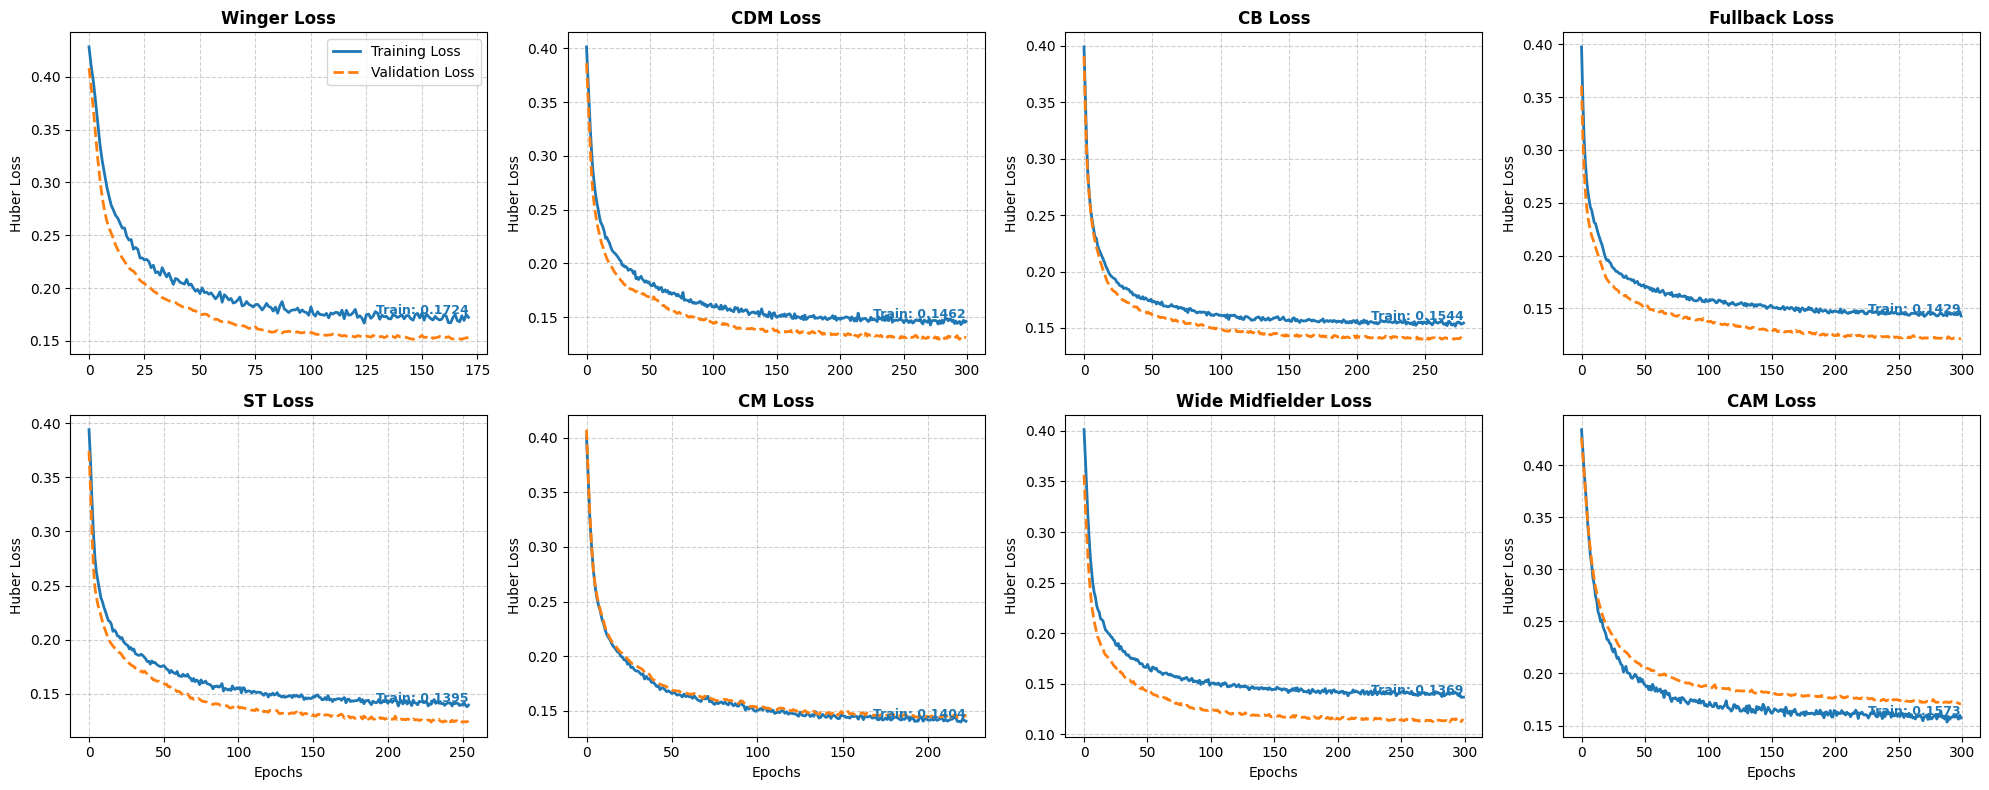


--- All Position-Specific Anomalies (Z-Score > 2.5) ---
Total anomalies found: 76


,player,age,team,pos,macro_pos,league,season,anomaly_score_z
835,Florian Lejeune,32,Rayo Vallecano,CB,CB,ESP-La Liga,2023 - 2024,13.455574
2472,Dejan Kulusevski,23,Tottenham,CM,CM,ENG-Premier League,2023 - 2024,13.030482
3171,Ruan,23,Sassuolo,RM,Wide Midfielder,ITA-Serie A,2022 - 2023,12.070736
780,Tim Ream,35,Fulham,CB,CB,ENG-Premier League,2023 - 2024,9.956641
1561,Jeremie Frimpong,22,Leverkusen,RB,Fullback,GER-Bundesliga,2023 - 2024,8.652774
1657,Kieran Trippier,31,Newcastle Utd,RB,Fullback,ENG-Premier League,2022 - 2023,8.349799
2150,Antoine Griezmann,31,Atlético Madrid,ST,ST,ESP-La Liga,2022 - 2023,8.015885
120,Lionel Messi,35,Paris S-G,RW,Winger,FRA-Ligue 1,2022 - 2023,7.630509
2794,Mohamed Salah,32,Liverpool,RM,Wide Midfielder,ENG-Premier League,2024 - 2025,7.600639
373,Hakan Çalhanoğlu,29,Inter,CDM,CDM,ITA-Serie A,2023 - 2024,7.179514


In [ ]:
# Remove noisy features from the original feature set before training the autoencoder
X_clean = X.drop(columns=noisy_columns, errors='ignore')
features_clean = [col for col in X.columns if col not in noisy_columns]

# Set up a loop to train an autoencoder for each macro-position and extract reconstruction errors
all_reconstruction_errors_by_pos = []
loss_curves_dict = {}
MIN_SAMPLES = 50 

for pos_name in unique_macro_positions:
    position_mask = df_info_reset['macro_pos'] == pos_name
    X_pos_raw = X_clean[position_mask.values] 
    df_info_pos = df_info_reset[position_mask].copy()
    n_samples = X_pos_raw.shape[0]
    print(f"\nProcessing macro-position: {pos_name} ({n_samples} players)...")
    
    # Check if there are enough samples to train an autoencoder
    if n_samples < MIN_SAMPLES:
        print(f"  ⚠️ Warning: Too few samples ({n_samples}). Skipping to prevent extreme overfitting.")
        continue

    # Split training and validation sets for this macro-position
    X_train_raw, X_val_raw = train_test_split(X_pos_raw, test_size=0.15, random_state=42)
    
    # Local scaler for this macro-position to prevent data leakage across positions
    scaler_pos = StandardScaler()
    X_train_scaled = scaler_pos.fit_transform(X_train_raw)
    X_val_scaled = scaler_pos.transform(X_val_raw)
    
    input_dim = X_train_scaled.shape[1]
    
    # Dynamic autoencoder architecture based on the number of samples in this macro-position
    input_layer = layers.Input(shape=(input_dim,))
    
    if n_samples >= 250:
        encoded = layers.Dense(32, activation='tanh')(input_layer)
        encoded = layers.Dropout(0.2)(encoded)
        encoded = layers.Dense(16, activation='tanh')(encoded)
        bottleneck = layers.Dense(8, activation='linear', name='dna_bottleneck')(encoded)
        decoded = layers.Dense(16, activation='tanh')(bottleneck)
        decoded = layers.Dense(32, activation='tanh')(decoded)
        decoded = layers.Dropout(0.2)(decoded)
        
    elif n_samples >= 100:
        encoded = layers.Dense(24, activation='tanh')(input_layer)
        encoded = layers.Dropout(0.2)(encoded)
        bottleneck = layers.Dense(6, activation='linear', name='dna_bottleneck')(encoded)
        decoded = layers.Dense(24, activation='tanh')(bottleneck)
        decoded = layers.Dropout(0.2)(decoded)
        
    else:
        encoded = layers.Dense(12, activation='tanh')(input_layer)
        bottleneck = layers.Dense(4, activation='linear', name='dna_bottleneck')(encoded)
        decoded = layers.Dense(12, activation='tanh')(bottleneck)

    output_layer = layers.Dense(input_dim, activation='linear')(decoded)
    
    # Compile and train the autoencoder for this macro-position
    autoencoder_pos = models.Model(inputs=input_layer, outputs=output_layer)
    autoencoder_pos.compile(optimizer='adam', loss='huber') 
    
    early_stop = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
    
    history = autoencoder_pos.fit(
        X_train_scaled, X_train_scaled,
        epochs=300,
        batch_size=16 if n_samples < 150 else 32,
        validation_data=(X_val_scaled, X_val_scaled),
        callbacks=[early_stop],
        verbose=0 
    )
    
    # Store the loss curves for this macro-position for later visualization
    loss_curves_dict[pos_name] = history.history
    
    # Compute reconstruction errors on the validation set to derive robust anomaly detection parameters
    X_val_reconstructed = autoencoder_pos.predict(X_val_scaled, verbose=0)
    val_reconstruction_errors = np.mean((X_val_scaled - X_val_reconstructed) ** 2, axis=1)
    
    # Compute median and MAD for the validation reconstruction errors
    val_median = np.median(val_reconstruction_errors)
    val_mad = np.median(np.abs(val_reconstruction_errors - val_median))
    val_mad = val_mad if val_mad > 0 else 1e-6 
    
    # Compute the 95th percentile of the validation reconstruction errors to set a threshold for anomaly detection
    anomaly_threshold_95 = np.percentile(val_reconstruction_errors, 95)
        
    # Compute reconstruction errors for all players in this macro-position using the trained autoencoder and the local scaler
    X_all_pos_scaled = scaler_pos.transform(X_pos_raw)
    X_reconstructed_pos = autoencoder_pos.predict(X_all_pos_scaled, verbose=0)
    reconstruction_errors_pos = np.mean((X_all_pos_scaled - X_reconstructed_pos) ** 2, axis=1)
    
    # Compute robust Z-score anomaly scores for all players in this macro-position based on the validation set parameters
    df_reconstruction_error_pos = df_info_pos.copy()
    df_reconstruction_error_pos['raw_reconstruction_error'] = reconstruction_errors_pos
    df_reconstruction_error_pos['robust_anomaly_score'] = (reconstruction_errors_pos - val_median) / val_mad
    df_reconstruction_error_pos['is_anomaly'] = reconstruction_errors_pos > anomaly_threshold_95
    
    # Save the reconstruction error DataFrame for this macro-position to the list for later aggregation and analysis
    all_reconstruction_errors_by_pos.append(df_reconstruction_error_pos)

print("\n--- Training Completed for All Macro-Positions ---")

# Plot loss curves for each macro-position to visually inspect training convergence and potential overfitting
if loss_curves_dict:
    print("\nGenerating Loss Convergence Plots...")
    num_plots = len(loss_curves_dict)
    
    cols = min(4, num_plots)
    rows = int(np.ceil(num_plots / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), sharex=False)
    axes = axes.flatten() if num_plots > 1 else [axes]
    
    for i, (pos_name, history) in enumerate(loss_curves_dict.items()):
        ax = axes[i]
        
        train_loss = history['loss']
        val_loss = history['val_loss']
        
        ax.plot(train_loss, color='#1f77b4', linewidth=2, label='Training Loss')
        ax.plot(val_loss, color='#ff7f0e', linewidth=2, linestyle='--', label='Validation Loss')
        
        ax.set_title(f"{pos_name} Loss", fontsize=12, fontweight='bold')
        ax.set_ylabel("Huber Loss")
        ax.grid(True, linestyle='--', alpha=0.6)
        
        if i == 0:
            ax.legend(loc='upper right')
        
        ax.text(len(train_loss)-1, train_loss[-1], f"Train: {train_loss[-1]:.4f}", 
                fontsize=9, va='bottom', ha='right', color='#1f77b4', weight='bold')
        
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    for ax in axes[-cols:]:
        ax.set_xlabel("Epochs")
        
    plt.tight_layout()
    plt.show()

# Compute final table of anomalies across all macro-positions, applying a Z-score threshold to identify statistically significant anomalies

if all_reconstruction_errors_by_pos:
    df_all_position_anomalies = pd.concat(all_reconstruction_errors_by_pos, ignore_index=True)
    
    # Z-score threshold of 2.5 to identify true anomalies
    df_true_anomalies = df_all_position_anomalies[df_all_position_anomalies['anomaly_score_z'] > 2.5]
    
    print(f"\n--- All Position-Specific Anomalies (Z-Score > 2.5) ---")
    print(f"Total anomalies found: {len(df_true_anomalies)}")
    
    columns_to_show = ['player', 'age', 'team', 'pos', 'macro_pos', 'league', 'season', 'anomaly_score_z']
    
    display(
        df_true_anomalies
        .sort_values(by='anomaly_score_z', ascending=False)[columns_to_show]
        .head(15)
    )
else:
    print("\nNo models trained due to insufficient data.")

In [ ]:
# Function to extract the top 3 features that most positively deviate from the macro-position median and the 3 features that most negatively deviate, for a given player index and macro-position

def get_player_feature_deviations(player_idx, macro_position, X_scaled, df_info_reset, features_original):
    position_mask = df_info_reset['macro_pos'] == macro_position
    position_median = np.median(X_scaled[position_mask], axis=0)
    player_profile = X_scaled[player_idx]
    
    # Calculate deviations
    deviations = player_profile - position_median
    
    # Get top 3 positive and worst 3 negative
    top_3_indices = np.argsort(deviations)[-3:][::-1]
    worst_3_indices = np.argsort(deviations)[:3] 
    
    # Format as individual strings with explicit "+" sign for positive deviations
    top_features = [f"{features_original[i]} (+{deviations[i]:.2f})" for i in top_3_indices]
    worst_features = [f"{features_original[i]} ({deviations[i]:.2f})" for i in worst_3_indices]
    
    # Pad with "-" if needed (safety check)
    while len(top_features) < 3:
        top_features.append("-")
    while len(worst_features) < 3:
        worst_features.append("-")
    
    return tuple(top_features + worst_features)

print("Extracting feature deviations for each anomalous player...")

top_1_list = []
top_2_list = []
top_3_list = []
worst_1_list = []
worst_2_list = []
worst_3_list = []

for idx, row in df_all_position_anomalies.iterrows():
    player_name = row['player']
    macro_position = row['macro_pos'] 
    team_name = row['team'] 
    
    # Find index of the player in the original df_info_reset to access their feature vector
    match_mask = (df_info_reset['player'] == player_name) & (df_info_reset['macro_pos'] == macro_position) & (df_info_reset['team'] == team_name)
    
    if not match_mask.any():
        match_mask = (df_info_reset['player'] == player_name) & (df_info_reset['macro_pos'] == macro_position)
        
    original_idx = df_info_reset[match_mask].index[0]
    
    # Extract feature deviations by passing the macro_position
    top_1, top_2, top_3, worst_1, worst_2, worst_3 = get_player_feature_deviations(
        original_idx, macro_position, X_scaled, df_info_reset, features_original
    )
    
    top_1_list.append(top_1)
    top_2_list.append(top_2)
    top_3_list.append(top_3)
    worst_1_list.append(worst_1)
    worst_2_list.append(worst_2)
    worst_3_list.append(worst_3)

# Assign the extracted feature deviations to new columns in the anomalies DataFrame for display
df_all_position_anomalies['Top_Feature_1'] = top_1_list
df_all_position_anomalies['Top_Feature_2'] = top_2_list
df_all_position_anomalies['Top_Feature_3'] = top_3_list
df_all_position_anomalies['Worst_Feature_1'] = worst_1_list
df_all_position_anomalies['Worst_Feature_2'] = worst_2_list
df_all_position_anomalies['Worst_Feature_3'] = worst_3_list

print("\nFinal Anomalies Table with Feature Deviations (Sorted by Robust Anomaly Score):")

# Define the columns to show in the final display and sort the anomalies by the robust anomaly score in descending order to highlight the most significant anomalies at the top of the table

columns_to_show = [
    'player', 'team', 'pos', 'macro_pos', 'robust_anomaly_score', 
    'Top_Feature_1', 'Top_Feature_2', 'Top_Feature_3', 
    'Worst_Feature_1', 'Worst_Feature_2', 'Worst_Feature_3'
]

df_display = df_all_position_anomalies.sort_values(by='robust_anomaly_score', ascending=False)

display(df_display[columns_to_show].head(15))

Extracting feature deviations for each anomalous player...



Final Anomalies Table with Feature Deviations (Sorted by Z-Score):


,player,team,pos,macro_pos,anomaly_score_z,Top_Feature_1,Top_Feature_2,Top_Feature_3,Worst_Feature_1,Worst_Feature_2,Worst_Feature_3
835,Florian Lejeune,Rayo Vallecano,CB,CB,13.455574,Standard_FK (+8.64),Long_Att (+3.03),Long_Cmp (+2.78),Take-Ons_Tkld% (-1.04),Expected_np:G-xG (-0.98),Expected_G-xG (-0.97)
2472,Dejan Kulusevski,Tottenham,CM,CM,13.030482,Carries_Dis (+3.58),Take-Ons_Tkld (+3.47),Touches_Att Pen (+2.84),preferred_foot_binary (-1.79),Long_Cmp% (-1.66),Expected_A-xAG (-1.61)
3171,Ruan,Sassuolo,RM,Wide Midfielder,12.070736,Performance_CrdR (+1.96),Long_Cmp% (+1.83),Blocks_Sh (+1.72),Progression_PrgR (-2.04),Receiving_PrgR (-2.04),Take-Ons_Att (-2.01)
780,Tim Ream,Fulham,CB,CB,9.956641,Expected_npxG/Sh (+18.36),Standard_G/Sh (+11.22),Standard_SoT% (+5.55),Standard_Dist (-2.66),preferred_foot_binary (-1.51),Playing Time_MP (-1.35)
1561,Jeremie Frimpong,Leverkusen,RB,Fullback,8.652774,Receiving_PrgR (+2.42),Progression_PrgR (+2.42),Take-Ons_Tkld (+1.90),Height (-1.26),Weight (-1.22),Int (-1.03)
1657,Kieran Trippier,Newcastle Utd,RB,Fullback,8.349799,Ast (+3.25),Performance_Ast (+3.25),Per 90 Minutes_Ast (+2.88),Take-Ons_Tkld% (-1.13),Height (-1.10),Take-Ons_Tkld (-0.65)
2150,Antoine Griezmann,Atlético Madrid,ST,ST,8.015885,Expected_xA (+2.35),Expected_xAG (+2.20),xAG (+2.20),Weight (-1.75),preferred_foot_binary (-1.75),Height (-1.41)
120,Lionel Messi,Paris S-G,RW,Winger,7.630509,Standard_FK (+8.09),Expected_xA (+6.41),PPA (+5.80),preferred_foot_binary (-1.45),Height (-1.40),Performance_CrdY (-1.01)
2794,Mohamed Salah,Liverpool,RM,Wide Midfielder,7.600639,Standard_PK (+8.75),Performance_PK (+8.75),Performance_PKatt (+7.51),preferred_foot_binary (-1.40),Performance_CrdY (-0.86),Challenges_Lost (-0.82)
373,Hakan Çalhanoğlu,Inter,CDM,CDM,7.179514,Standard_PKatt (+3.33),Performance_PKatt (+3.33),Performance_PK (+2.86),Blocks_Pass (-1.34),Tackles_Def 3rd (-1.31),Weight (-1.02)


## End

In [ ]:
end_time = time.time()

In [ ]:

elapsed_time = end_time - start_time
elapsed_minutes = round(elapsed_time / 60)
remaining_seconds = round(elapsed_time % 60)
print(f"\nTotal execution time: {elapsed_minutes:.0f}.{remaining_seconds:.0f} min")


Total execution time: 21.25 min
